# Regulation Elements

In this notebook, we will explore the usage of regulatory elements in Autoware lanelet2.

## Lanelet2 Regulatory Elements
Lanelet2 defined a set of regulatory elements to imply special regions and rules.

### Common Code/Access Structure
- The set of regulatory elements can be found/accessed as

     - `laneletMap.regulatoryElementLayer.get` : get from ID
     - `laneletMap.regulatoryElementLayer.search`: search in bounding boxes
     - `laneletMap.regulatoryElementLayer.nearest`: the the nearst n elements.
     - `for element in laneletMap.regulatoryElementLayer`: iterate through the map

- We can access the regulatory elements that are explicitly connected to lanelets (some of the TIER IV maps does not annotate all of the elements in an lanelets)

     - `lanelet.regulatoryElements`: as a list of RegulatoryElement objects.
     - `lanelet.trafficLights()`: get all the related traffic light elements (including the extended `AutowareTrafficLight`)
     - `lanelet.trafficSigns()`: get all the traffic sign objects related to the lanelet.
     - `lanelet.speedLimits()` : get all the speed limit elements related to the lanelet.
     - `lanelet.rightOfWay()` :  get all the right-of-way elements related to the lanelet.
     - `lanelet.allWayStop()`:   get all the all-way-stop elements related to the lanelet.

In [1]:
## source setup.bash after build and install
!source setup.bash

from autoware_lanelet2_extension_python.projection import MGRSProjector
import autoware_lanelet2_extension_python.utility.query as query
import autoware_lanelet2_extension_python.utility.utilities as utilities
from autoware_lanelet2_extension_python.regulatory_elements import *
import lanelet2

# MGRS Projector will be the default projector without a projector into file
projector = MGRSProjector(lanelet2.io.Origin(0.0, 0.0))

Environment setup complete:
PYTHONPATH = /home/ukenryu/map_test/lanelet2_python_api_for_autoware/install/lib/python3/dist-packages:/home/ukenryu/map_test/lanelet2_python_api_for_autoware/install/lib/python3/dist-packages:/home/ukenryu/map_test/lanelet2_python_api_for_autoware/install/lib/python3/dist-packages:/home/ukenryu/map_test/lanelet2_python_api_for_autoware/install/lib/python3/dist-packages:
LD_LIBRARY_PATH = /home/ukenryu/map_test/lanelet2_python_api_for_autoware/install/lib:/home/ukenryu/map_test/lanelet2_python_api_for_autoware/install/lib:/usr/local/cuda/lib64:
PATH = /home/ukenryu/map_test/lanelet2_python_api_for_autoware/install/lib:/home/ukenryu/map_test/lanelet2_python_api_for_autoware/install/lib:/home/ukenryu/.easy_autoware/scenario_sim/scripts:/home/ukenryu/.easy_autoware/scripts:/usr/local/cuda/bin:/home/ukenryu/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin:/home/ukenryu/.local/bin:/home/ukenry

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<lanelet::ConstLineString3d, std::allocator<lanelet::ConstLineString3d> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<lanelet::ConstPolygon3d, std::allocator<lanelet::ConstPolygon3d> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<lanelet::ConstLanelet, std::allocator<lanelet::ConstLanelet> > already registered; second conversion method ignored.


![image](tutorial_docs/odaiba_lanelet1017.png)

In [2]:
## PLEASE Change the path to your path
lanelet2_path = "/home/ukenryu/autoware_map/odaiba_stable/lanelet2_map.osm"

In [3]:
## Load the map, get the lanelets first as before

odaiba_map = lanelet2.io.load(lanelet2_path, projector)

lanelet1017 = odaiba_map.laneletLayer.get(1017)
lanelet1017.regulatoryElements

[AutowareTrafficLight(10330, {'light_bulbs': [<lanelet2.core.LineString3d object at 0x7ff9f0043140>], 'ref_line': [<lanelet2.core.LineString3d object at 0x7ff9f0043300>], 'refers': [<lanelet2.core.LineString3d object at 0x7ff9f0043370>]}, <lanelet2.core.AttributeMap object at 0x7ffa0c79fb00>),

In [4]:
lanelet1017.regulatoryElements[0].lightBulbs()[0]

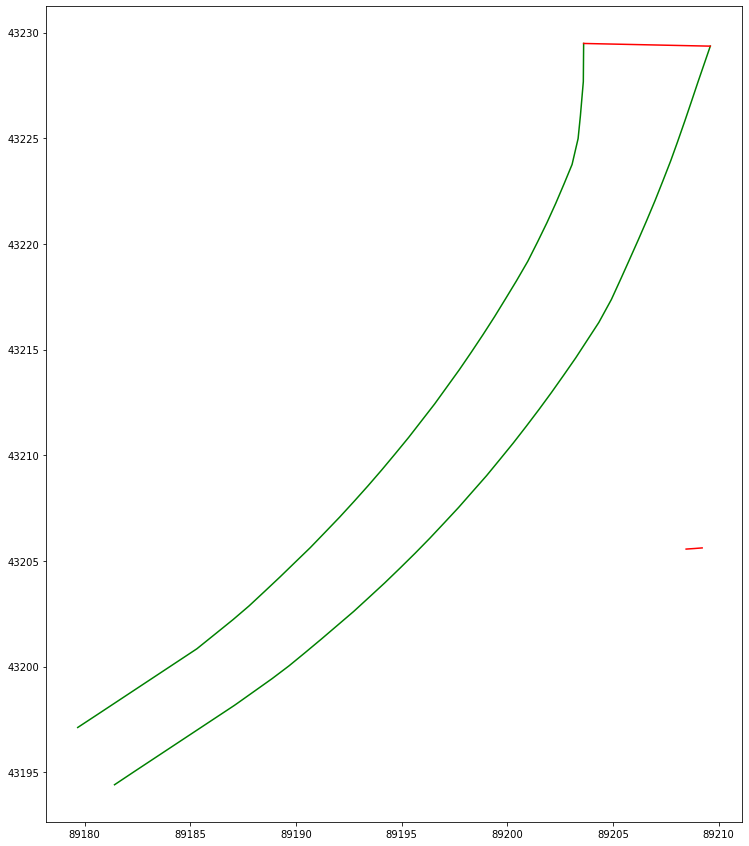

In [5]:
traffic_light_location = odaiba_map.regulatoryElementLayer.get(lanelet1017.regulatoryElements[0].id).lightBulbs()[0]
stop_line = lanelet1017.regulatoryElements[0].stopLine

import matplotlib.pyplot as plt
def plot_linestring(linestring, ax:plt.Axes, color, linestyle, **kwargs):
    xs = [pt.x for pt in linestring]
    ys = [pt.y for pt in linestring]
    ax.plot(xs, ys, color=color, linestyle=linestyle, **kwargs)

fig, ax = plt.subplots(figsize=(20, 15))
plot_linestring(lanelet1017.leftBound, ax, "green", "-")
plot_linestring(lanelet1017.rightBound, ax, "green", "-")
plot_linestring(traffic_light_location, ax, "red", "-")
plot_linestring(stop_line, ax, "red", "-")

ax.set_aspect('equal')

## Autoware Extension for Regulation Elements

Autoware Extension introduces enhancements to the basic lanelet2 with additional *types of polygon*, *subtypes of lanelet*, *addtional attributes of lanelet*, *new classes of regulatory elements*

For polygon areas including `crosswalk`/`bus_stop_area`/`detection_area`/`no_parking_area`/`no_stopping_area`/`road_marking`/`intersection_area`
- All these polygons can be access the `laneletMap.polygonLayer`, with `.get`, `.search`, `__iter__` methods
- `no_stopping_area`, `crosswalks`... can be accessed from *correctly annotated* lanelets, within `lanelet.regulatoryElements`.
- `intersection_area` needs to be accessed from *correctly annotated lanelets* using **attributes**. (because it is an optional tags instead)
- Access the `turn_direction` attributes, for winker signals.

In [6]:
def attribute_or(lanelet, key, default):
    if key in lanelet.attributes:
        return lanelet.attributes[key]
    return default

def is_private_road(lanelet):
    return attribute_or(lanelet, "subtype", "road") == "private"

def get_road_subtype(lanelet):
    return attribute_or(lanelet, "subtype", "road")

def is_intersection_area(lanelet):
    return attribute_or(lanelet, "intersection_area", None)  is not None

def get_intersection_area_polygon_id(lanelet):
    return attribute_or(lanelet, "intersection_area", None)

def get_turn_direction(lanelet):
    return attribute_or(lanelet, "turn_direction", "straight")

def get_speed_limit(lanelet):
    return attribute_or(lanelet, "speed_limit", None)

def get_crosswalk(lanelet):
    regulatory_elements = lanelet.regulatoryElements
    for regulatory_element in regulatory_elements:
        if isinstance(regulatory_element, Crosswalk):
            return regulatory_element
    return None

def get_no_parking_area(lanelet):
    regulatory_elements = lanelet.regulatoryElements
    for regulatory_element in regulatory_elements:
        if isinstance(regulatory_element, NoParkingArea):
            return regulatory_element
    return None

In [7]:
intersection_id = get_intersection_area_polygon_id(lanelet1017)
intersection_id

'300006'

In [8]:
polygon = odaiba_map.polygonLayer.get(int(intersection_id))
polygon

speed_limit=60
turn_direction=right


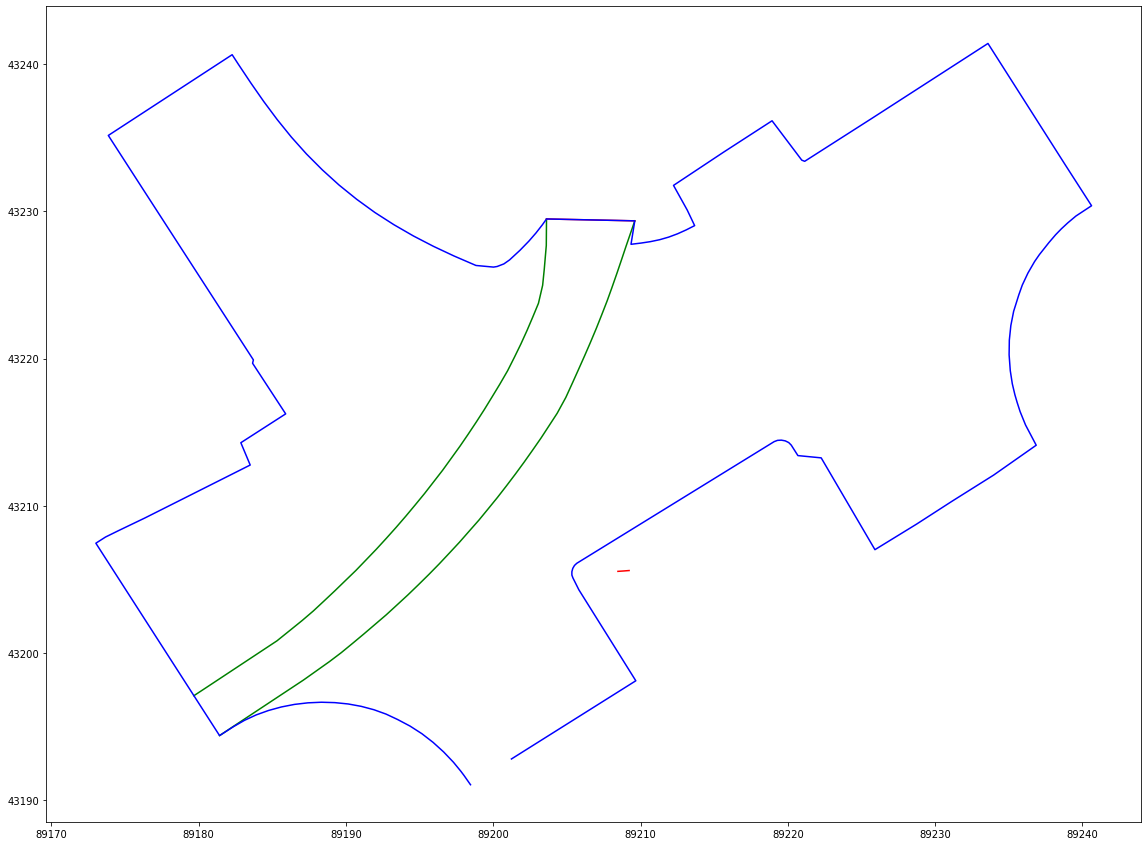

In [9]:
traffic_light_location = odaiba_map.regulatoryElementLayer.get(lanelet1017.regulatoryElements[0].id).lightBulbs()[0]
stop_line = lanelet1017.regulatoryElements[0].stopLine

import matplotlib.pyplot as plt
def plot_linestring(linestring, ax:plt.Axes, color, linestyle, **kwargs):
    xs = [pt.x for pt in linestring]
    ys = [pt.y for pt in linestring]
    ax.plot(xs, ys, color=color, linestyle=linestyle, **kwargs)

fig, ax = plt.subplots(figsize=(20, 15))
plot_linestring(lanelet1017.leftBound, ax, "green", "-")
plot_linestring(lanelet1017.rightBound, ax, "green", "-")
plot_linestring(traffic_light_location, ax, "red", "-")
plot_linestring(stop_line, ax, "red", "-")
plot_linestring(polygon, ax, "blue", "-")

ax.set_aspect('equal')

print(f"speed_limit={get_speed_limit(lanelet1017)}")
print(f"turn_direction={get_turn_direction(lanelet1017)}")